# RQ2 — Challenges Faced During Data Science Project Development

**RQ2:** *What are the challenges the practitioners are facing during the data science project development?*

**Analyses:**
1. DS-process challenge severity — descriptive ranking
2. Kruskal-Wallis H test: challenge severity ~ practitioner role
3. Dunn's post-hoc for significant challenge (Learning Curve in Data Exploration)
4. Spearman correlation: DS/SE experience vs challenge severity
5. SE challenge prevalence ranking
6. SE challenge co-occurrence (top pairs)


In [1]:
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import scikit_posthocs as sp
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from analysis_utils import (
    load_data,
    DS_CHALLENGE_COLS, DS_CHALLENGE_LABELS,
    SE_CHALLENGE_COLS, SE_CHALLENGE_LABELS,
)

warnings.filterwarnings('ignore')
df = load_data()
N  = len(df)
print(f"Dataset loaded: {N} respondents")

Dataset loaded: 112 respondents


## 1. DS-Process Challenge Severity Ranking (scale 0–5)

In [2]:
rows = []
for c in DS_CHALLENGE_COLS:
    if c not in df.columns:
        continue
    vals = df[c].dropna()
    rows.append({
        'Challenge': DS_CHALLENGE_LABELS[c],
        'n':         len(vals),
        'Mean':      round(vals.mean(), 3),
        'Median':    vals.median(),
        'SD':        round(vals.std(), 3),
    })

rank_df = pd.DataFrame(rows).sort_values('Mean', ascending=False).reset_index(drop=True)
display(rank_df)

,Challenge,n,Mean,Median,SD
0,Data cleansing [DP],84,3.405,4.0,1.336
1,Data inconsistency/drift [DP],87,3.379,4.0,1.232
2,New/unplanned feature requests [BU],87,3.345,4.0,1.237
3,Incomplete data [DP/DU],86,3.314,3.5,1.239
4,Misunderstanding DS/users [BU],87,3.126,3.0,1.237
5,Learning curve in data exploration [DU],87,3.000,3.0,1.191
6,Data assertion/observability [DP/M],85,2.906,3.0,1.377
7,Fixing model bugs [MOD],87,2.885,3.0,1.324
8,Model monitoring [DP/M],87,2.782,3.0,1.350


## 2. Kruskal-Wallis H Test: Challenge Severity ~ Role

In [3]:
kw_rows = []
for c in DS_CHALLENGE_COLS:
    if c not in df.columns:
        continue
    groups = [
        grp[c].dropna().values
        for _, grp in df.groupby('role')
        if len(grp[c].dropna()) >= 3
    ]
    if len(groups) < 2:
        continue
    h, p = stats.kruskal(*groups)
    kw_rows.append({
        'Challenge':   DS_CHALLENGE_LABELS[c],
        'H-Statistic': round(h, 3),
        'p-value':     round(p, 4),
        'Sig. (p<.05)': '*' if p < 0.05 else '',
    })

display(pd.DataFrame(kw_rows))

,Challenge,H-Statistic,p-value,Sig. (p<.05)
0,Misunderstanding DS/users [BU],3.185,0.7853,
1,New/unplanned feature requests [BU],4.111,0.6616,
2,Data cleansing [DP],6.950,0.3255,
3,Data inconsistency/drift [DP],6.827,0.3372,
4,Incomplete data [DP/DU],8.671,0.1930,
5,Learning curve in data exploration [DU],12.888,0.0449,*
6,Data assertion/observability [DP/M],2.562,0.8614,
7,Model monitoring [DP/M],0.405,0.9988,
8,Fixing model bugs [MOD],6.702,0.3493,


## 3. Dunn's Post-Hoc — Learning Curve in Data Exploration [DU]

Significant at H=12.89, p=0.045. Adjusted threshold: α' = 0.05 / 21 ≈ 0.0024

In [4]:
LC_COL = 'challenge_learning_curve_data_exploration_[du]'
tmp = df[['role', LC_COL]].dropna()

desc_role = tmp.groupby('role')[LC_COL].agg(
    n='count', Median='median', Mean='mean', SD='std'
).round(2).reset_index()
print("Per-role descriptives:")
display(desc_role)

Per-role descriptives:


,role,n,Median,Mean,SD
0,Data Analyst,19,3.0,3.00,1.29
1,Data Engineer,15,3.0,2.73,1.10
2,Data Scientist,14,4.0,3.71,0.91
3,ML Engineer,6,4.0,3.67,1.03
4,Others,12,3.0,3.08,1.16
5,Programmer/SW Dev.,14,2.5,2.64,1.15
6,Project Manager,7,2.0,2.14,1.21


In [5]:
dunn_mat = sp.posthoc_dunn(tmp, val_col=LC_COL, group_col='role', p_adjust='bonferroni')

roles = list(dunn_mat.columns)
pairs = []
for i in range(len(roles)):
    for j in range(i + 1, len(roles)):
        ra, rb = roles[i], roles[j]
        p_bonf = dunn_mat.loc[ra, rb]
        p_raw  = p_bonf / 21
        pairs.append({'Role A': ra, 'Role B': rb,
                      'p_raw': round(p_raw, 4), 'p_Bonf': round(p_bonf, 4)})

pairs_df = pd.DataFrame(pairs).sort_values('p_raw').reset_index(drop=True)
display(pairs_df)

,Role A,Role B,p_raw,p_Bonf
0,Data Scientist,Project Manager,0.0059,0.1244
1,Data Scientist,Programmer/SW Dev.,0.0132,0.2763
2,ML Engineer,Project Manager,0.0231,0.4845
3,Data Engineer,Data Scientist,0.0270,0.5680
4,Data Analyst,Data Engineer,0.0476,1.0000
5,Others,Programmer/SW Dev.,0.0476,1.0000
6,ML Engineer,Programmer/SW Dev.,0.0476,1.0000
7,ML Engineer,Others,0.0476,1.0000
8,Data Scientist,Others,0.0476,1.0000
9,Data Scientist,ML Engineer,0.0476,1.0000


## 4. Spearman Correlation: Experience vs DS Challenge Severity

In [6]:
results = []
for exp_col, exp_label in [('ds_exp', 'DS experience'), ('se_exp', 'SE experience')]:
    for c in DS_CHALLENGE_COLS:
        if c not in df.columns:
            continue
        tmp = df[[exp_col, c]].dropna()
        if len(tmp) < 6:
            continue
        rho, p = stats.spearmanr(tmp[exp_col], tmp[c])
        results.append({
            'Experience':  exp_label,
            'Challenge':   DS_CHALLENGE_LABELS[c],
            'rho':         round(rho, 3),
            'p-value':     round(p, 4),
            'Sig. (p<.05)': '*' if p < 0.05 else '',
        })

corr_df = pd.DataFrame(results)
display(corr_df)

,Experience,Challenge,rho,p-value,Sig. (p<.05)
0,DS experience,Misunderstanding DS/users [BU],0.130,0.2309,
1,DS experience,New/unplanned feature requests [BU],0.072,0.5100,
2,DS experience,Data cleansing [DP],-0.063,0.5688,
3,DS experience,Data inconsistency/drift [DP],-0.006,0.9526,
4,DS experience,Incomplete data [DP/DU],0.049,0.6534,
5,DS experience,Learning curve in data exploration [DU],-0.013,0.9037,
6,DS experience,Data assertion/observability [DP/M],-0.049,0.6560,
7,DS experience,Model monitoring [DP/M],-0.032,0.7716,
8,DS experience,Fixing model bugs [MOD],-0.051,0.6374,
9,SE experience,Misunderstanding DS/users [BU],0.062,0.5688,


## 5. SE Challenge Prevalence

In [7]:
se_rows = []
for c in SE_CHALLENGE_COLS:
    bin_col = c + '_bin'
    if bin_col not in df.columns:
        continue
    n_sel = int(df[bin_col].sum())
    se_rows.append({
        'SE Challenge': SE_CHALLENGE_LABELS[c],
        'n':            n_sel,
        '%':            round(n_sel / N * 100, 1),
    })

se_df = pd.DataFrame(se_rows).sort_values('%', ascending=False).reset_index(drop=True)
display(se_df)

,SE Challenge,n,%
0,Requirement changes mid-project,52,46.4
1,Requirements gathering issues,51,45.5
2,Many stakeholders (hard to manage),34,30.4
3,No integration/load testing,28,25.0
4,Code maintenance and reuse,25,22.3
5,No version control,16,14.3


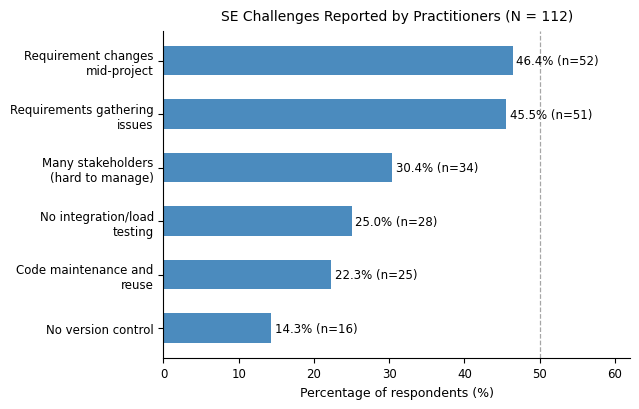

Saved fig_se_challenge_pct.pdf/.png


In [8]:
import matplotlib
import matplotlib.pyplot as plt
import textwrap
import os

# --- Build sorted data ---
fig_rows = []
for c in SE_CHALLENGE_COLS:
    bin_col = c + '_bin'
    if bin_col not in df.columns:
        continue
    n_sel = int(df[bin_col].sum())
    fig_rows.append({
        'label': SE_CHALLENGE_LABELS[c],
        'n':     n_sel,
        'pct':   round(n_sel / N * 100, 1),
    })
fig_rows.sort(key=lambda x: x['pct'])  # ascending so top bar = highest

labels = ['\n'.join(textwrap.wrap(r['label'], width=22)) for r in fig_rows]
pcts   = [r['pct'] for r in fig_rows]
ns     = [r['n']   for r in fig_rows]

# --- Plot ---
bar_color = '#4B8BBE'
fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.barh(labels, pcts, color=bar_color, edgecolor='none', height=0.55)

for bar, pct, n in zip(bars, pcts, ns):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{pct}% (n={n})', va='center', ha='left', fontsize=8.5)

ax.axvline(50, color='grey', linestyle='--', linewidth=0.9, alpha=0.7)
ax.set_xlim(0, 62)
ax.set_xlabel('Percentage of respondents (%)', fontsize=9)
ax.set_title(f'SE Challenges Reported by Practitioners (N = {N})', fontsize=10, pad=8)
ax.tick_params(axis='y', labelsize=8.5)
ax.tick_params(axis='x', labelsize=8.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# --- Save ---
out_dir = os.path.join(os.path.dirname(os.getcwd()), '') if os.path.basename(os.getcwd()) == 'replication package' else ''
fig.savefig(os.path.join('..', 'fig_se_challenge_pct.pdf'), bbox_inches='tight')
fig.savefig(os.path.join('..', 'fig_se_challenge_pct.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved fig_se_challenge_pct.pdf/.png")

## 6. SE Challenge Co-occurrence (Top Pairs)

In [9]:
bin_cols = [c + '_bin' for c in SE_CHALLENGE_COLS if c + '_bin' in df.columns]
labels   = {c + '_bin': SE_CHALLENGE_LABELS[c] for c in SE_CHALLENGE_COLS}
pairs = []
for i in range(len(bin_cols)):
    for j in range(i + 1, len(bin_cols)):
        c1, c2 = bin_cols[i], bin_cols[j]
        co = int(((df[c1] == 1) & (df[c2] == 1)).sum())
        pairs.append({
            'Challenge A': labels[c1],
            'Challenge B': labels[c2],
            'n':           co,
            '%':           round(co / N * 100, 1),
        })

cooc_df = pd.DataFrame(pairs).sort_values('n', ascending=False).reset_index(drop=True)
display(cooc_df.head(10))

,Challenge A,Challenge B,n,%
0,Requirement changes mid-project,Requirements gathering issues,33,29.5
1,Many stakeholders (hard to manage),Requirement changes mid-project,24,21.4
2,Many stakeholders (hard to manage),Requirements gathering issues,20,17.9
3,Requirement changes mid-project,Code maintenance and reuse,17,15.2
4,No integration/load testing,Requirement changes mid-project,16,14.3
5,No integration/load testing,Requirements gathering issues,15,13.4
6,Requirements gathering issues,Code maintenance and reuse,15,13.4
7,Many stakeholders (hard to manage),No integration/load testing,10,8.9
8,Many stakeholders (hard to manage),Code maintenance and reuse,10,8.9
9,Requirement changes mid-project,No version control,10,8.9
